In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from joblib import load

# Data Analysis

In [2]:
df_analysis = load('df_analysis.joblib')


In [3]:
df_analysis.head()

,OverTime,TotalWorkingYears,JobLevel,MaritalStatus,YearsInCurrentRole,MonthlyIncome,Age,YearsWithCurrManager,StockOptionLevel,YearsAtCompany,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,Attrition
0,Yes,8,2,Single,4,5993,41,5,0,6,3,4,2,Yes
1,No,10,2,Married,7,5130,49,7,1,10,2,2,3,No
2,Yes,7,1,Single,0,2090,37,0,0,0,2,3,4,Yes
3,Yes,8,1,Married,7,2909,33,0,0,8,3,3,4,No
4,No,6,1,Married,2,3468,27,2,1,2,3,2,1,No


In [4]:
print(f"Total employees: {len(df_analysis)}")
print(f"Attrition rate: {df_analysis['Attrition'].value_counts(normalize=True)['Yes']:.1%}")

Total employees: 1470
Attrition rate: 16.1%


<Figure size 800x500 with 0 Axes>

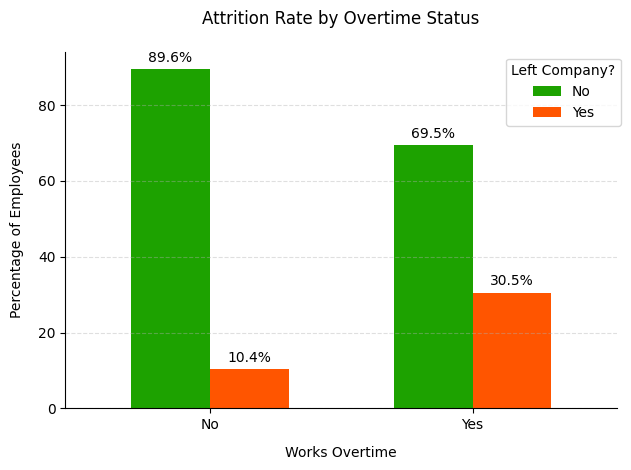

In [49]:
# Calculate percentages
attrition_rate = df_analysis.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100

# Plot
plt.figure(figsize=(8,5))
ax = attrition_rate.plot(kind='bar', 
                        stacked=False,
                        color=['#1DA200', '#ff5500'],  # Green: No, Orange: Yes
                        width=0.6)

plt.title('Attrition Rate by Overtime Status', pad=20)
plt.ylabel('Percentage of Employees', labelpad=10)
plt.xlabel('Works Overtime', labelpad=10)
plt.xticks(rotation=0)
plt.legend(title='Left Company?', labels=['No', 'Yes'], 
           bbox_to_anchor=(1.02, 1))  # Logical order

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

# Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

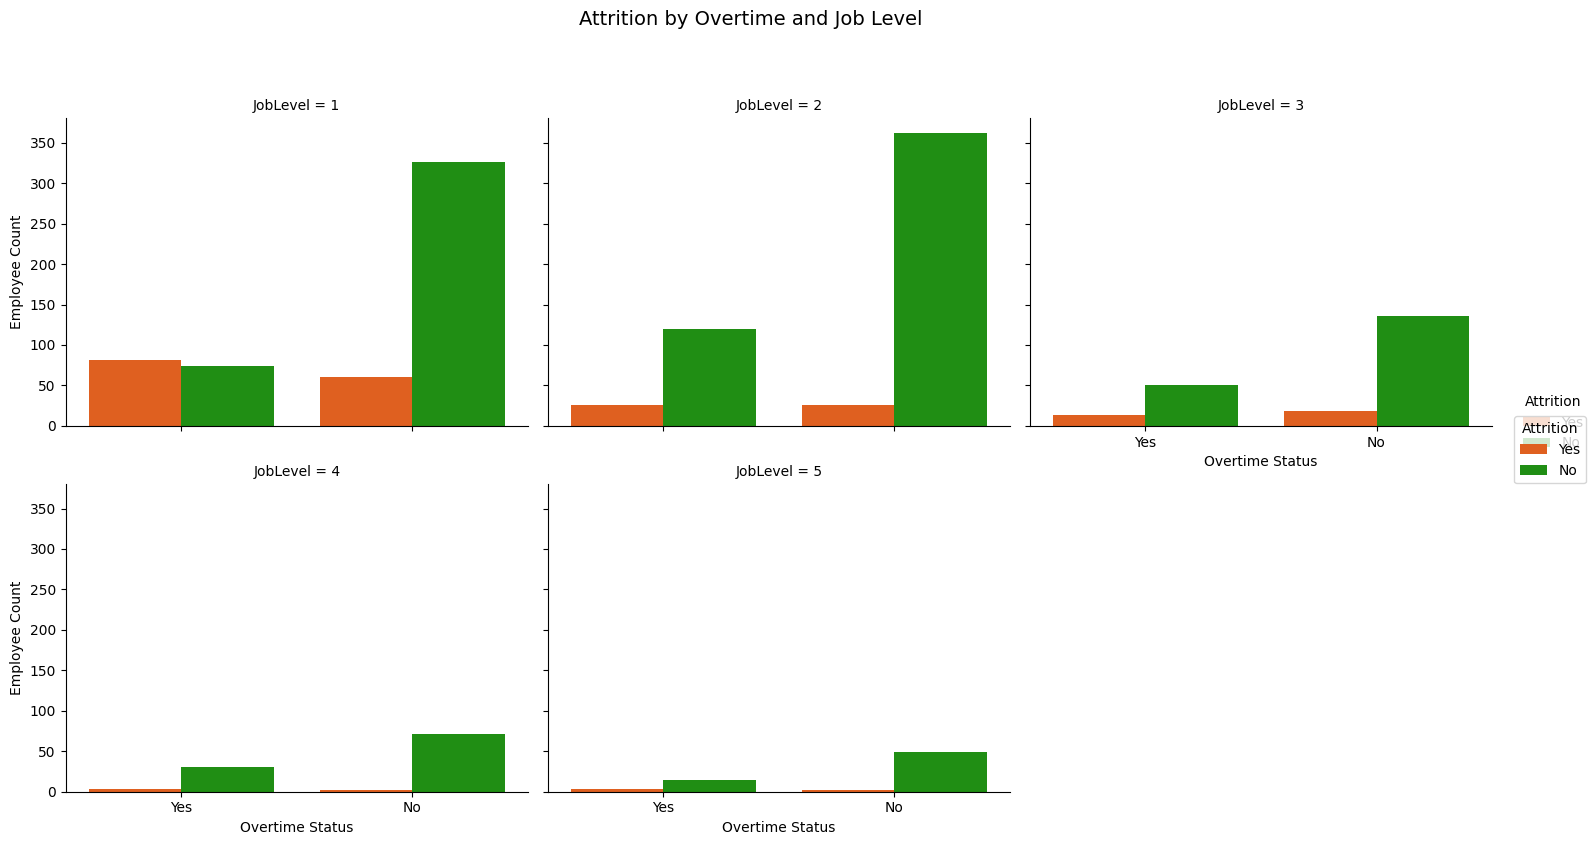

In [82]:
g = sns.catplot(
    data=df_analysis, 
    x="OverTime", 
    col="JobLevel",
    hue="Attrition", 
    kind="count",
    palette=["#FF5500", "#10A200"],  # Green: No, Orange: Yes
    col_wrap=3, 
    height=4, 
    aspect=1.2,

)

# Proper labeling
g.set_axis_labels("Overtime Status", "Employee Count")
g.figure.suptitle('Attrition by Overtime and Job Level', y=1.05, fontsize=14)
g.figure.legend(title='Attrition', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

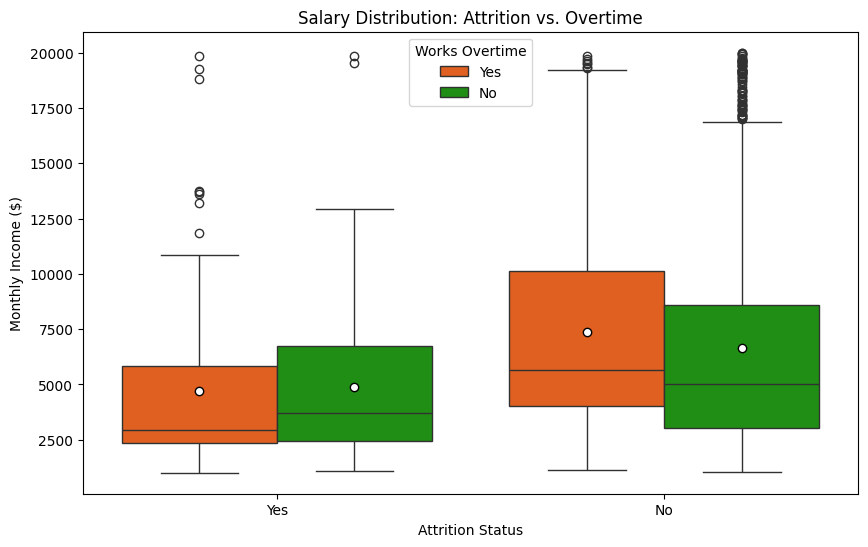

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analysis, x='Attrition', y='MonthlyIncome', 
           hue='OverTime', 
           palette={'Yes': '#FF5500', 'No': '#10A200'},  # Matches catplot colors#ff5500
           showmeans=True,
           meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title('Salary Distribution: Attrition vs. Overtime')
plt.ylabel('Monthly Income ($)')
plt.xlabel('Attrition Status')
plt.legend(title='Works Overtime')
plt.show()

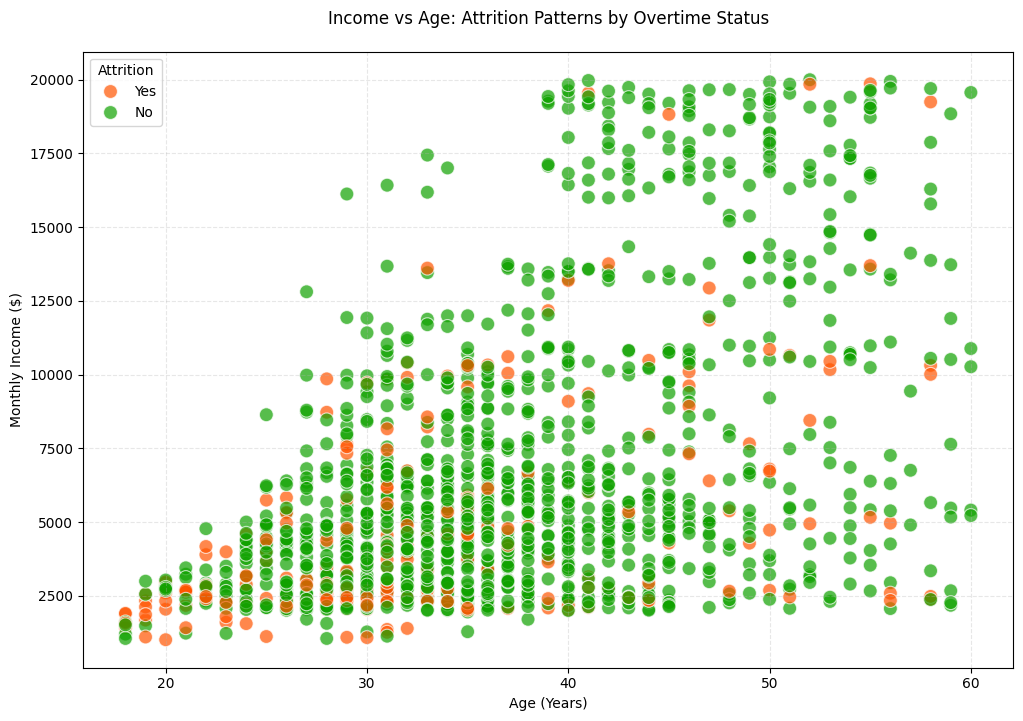

In [9]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_analysis,
    x='Age',
    y='MonthlyIncome',
    hue='Attrition',
    palette={'Yes': '#FF5500', 'No': '#10A200'},
    s=100,  # Control point size
    alpha=0.7  # Slight transparency
)

plt.title('Income vs Age: Attrition Patterns by Overtime Status', pad=20)
plt.xlabel('Age (Years)')
plt.ylabel('Monthly Income ($)')
plt.grid(True, linestyle='--', alpha=0.3)


plt.show()